In [2]:
%load_ext autoreload
%autoreload 2

'''
Importing the modules
'''
import config_2Dcoupling_V3 as cfg              # config = physical & simulation parameters 
from solver_Hcurl_2D_V3 import *                # solver = FEM method + pmls
import diagnostic_post_process_V3 as my_pp      # post_process = plotting functions


mesh_save_dir = /Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V3/Meshes
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
solver = LHCouplingSolver_2DHcurl_1DH1(cfg.__dict__)
solver.build_physics_Stix_B_field(lambda x, z: my_pp.create_density_profile(x, z, solver))
mesh = solver.build_mesh_with_PMLs()
# print('num_vertices = ', mesh.nv)

GF_E_field, _ = solver.solve_helmholtz_Hcurl_3D_pml(mesh)

--- [Create_density_profile]: is_ngsolve = True ---
create_density_profile: prof_type = constant_density
ne = 5e+18, type(ne) = <class 'float'>
--- n_para = 2.0 and Golant_acc_crit = 1.0375756770853268 ---
k0_vacuum = 77.546 m-1
--- n_para = 2.0 is != 0 ---
lambda_z = 0.041 m
lambda_z_multiple = 2.000
Then Lz_exact = 0.081 m
n_perp_plus = 80.6768 ; n_perp_minus =  -2.6422
n_perp_max = 80.6768 m-1
lambda_min = 0.001 m
h_max = 0.0003 m
--- Generating 2.5D Mesh ---
Lx_tot type =  <class 'float'> Lz type =  <class 'float'>
2D flat plane: X=0.050m, Z=0.081m
--- The facees are set ---
--- The faces are glued ---
--- z periodicity set ok ---
--- Mesh was generated ---
--- Saving mesh to: /Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V3/Meshes/my_lh_mesh.vol ---
#DoFs = 1409846 (= number of mesh points).
--- Solving the 3D vector linear system ---
--- System solved ---



[SYSTEM] Dossier de sauvegarde créé : Simulation_Results/Run_20260430_140847
sim_target_folder:  /Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V3/Simulation_Results/Run_20260430_140847
Generating 2D wave E map...


AttributeError: module 'matplotlib.pyplot' has no attribute 'scaled'

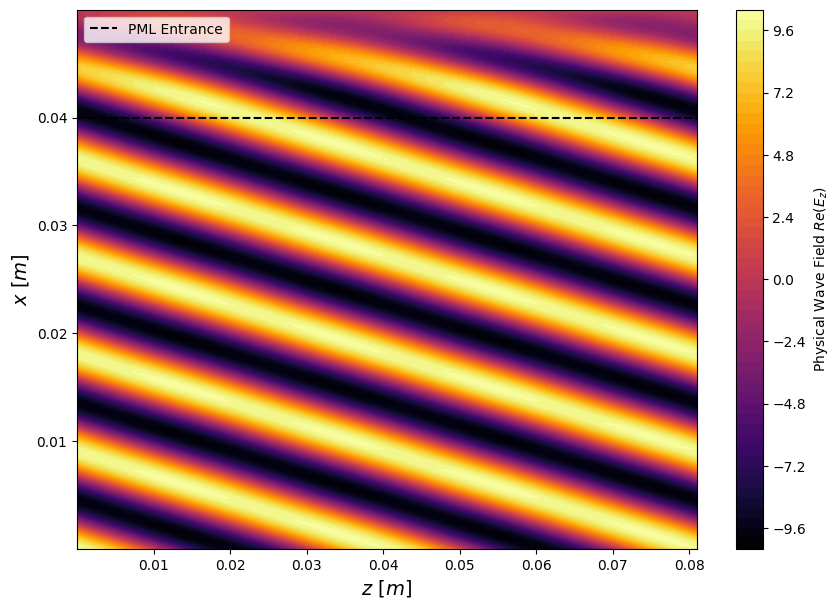

In [9]:
# Post-treatment:

run_folder = my_pp.setup_output_directory("Simulation_Results")
sim_target_folder = '/Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V3/' + run_folder
print('sim_target_folder: ', sim_target_folder)

my_pp.plot_wave_2D(mesh, GF_E_field)


resolution_x, resolution_z = 500, 500 
# my_pp.Plot_E_field_2D_Map(solver, sim_target_folder, resolution_x, resolution_z, component ='Ez')

In [ ]:
# Pour faire des boucles sur les params de config_dict

cfg.DOMAIN['Lx_plasma'] = 30.
print(cfg.DOMAIN['Lx_plasma'] )



30.0
